# Experiment Analysis

### Hyperparameter space
|Hyperparameter|Type|Range (Original)|Range(Paper)|
|--|--|--|--|
|n_layers |IntDistribution |[1,4]|[1,4]|
|embedding_dim |CategoricalDistribution |[32, 64, 96, 128]|[32, 64, 96, 128, **256**]|
|lr |FloatDistribution (log) |[1e-5, 1e-1]|[1e-5, 1e-1]|
|lambda_val |FloatDistribution (log) |[1e-6, 1e-1]|[1e-6, 1e-1]|
|batch_size |IntDistribution |[512, 2,048]|[512, **4,096**]|
|optimizer |CategoricalDistribution |[Adam, RMSprop, SGD]|[Adam, RMSprop, SGD]|

### 100K Dataset

| Run | Best | Trials | Epochs | Eval<br>every | Filter | Train/test<br>split | Epoch<br>metrics | Stoppage | Optuna<br>reporting | Objective | Prunning | MOO | Dominant set<br>calculation | Models | Results|
|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|
|0 | |100 | 10,000 | 200 | `eval > 3` | Random | No | None | Last | Recall |Yes|No| Loose | All models  | First run after correcting loss function |
|1 | |200 | 10,000 | 200 | `eval > 3` | Random | No | None | Last | Recall |Yes|No| Loose | All models | Running more epochs to get a better model |
|2 | |200 | 10,000 | 200 | `eval > 3` | Random | No | None | Last | Recall |Yes|No| Loose/Strict | All models | Saw overfitting, but didn't have the metric values |
|3 | |200 | 10,000 | 200 | `eval > 3` | Structural | Yes | None | Last  | Recall |Yes|No| Loose/Strict | - Full graph <br> - Dominant sets | Noticed that by running all 10,000 epocs had lower recall|
|4 | |200 | 4,000 | 50 | `eval > 3` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | Full graph  | Added early stoppage and best recall reporting to get better models |
|5 | |200 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | Full graph | We should include all reviews, not only the good ones<br>Light GCN is only about interactions. |
|6 | * |300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | All models | Since last model worked better for Full graph, running for all |
|7 |  |300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | All models | Trained the random sets based on the best parameters for each the dominant set |
|8 | * |300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | NDCG |No|Yes| Loose/Strict | All models | Added the MOO and focused on NDCG |

### 1M Dataset

| Run | Best | Trials | Epochs | Eval every | Filter | Train/test<br>split | Epoch<br>metrics | Stoppage | Optuna<br>objective |  Objective | Prunning | MOO  | Dominant set<br>calculation | Models | Results|
|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|
|0 | | 100 | 10,000 | 200 | `eval > 3` | Random | No | None | Last | Recall |Yes|No| Loose | All models  | First run after correcting loss function |
|1 | * | 300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | All models | Using iterations from 100K, results seem more consistent |
|2 |  | 300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | All models |Trained the random sets based on the best parameters <br>for each the dominant set as in the 100K |
|2 | * | 300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | NDCG |No|Yes| Loose/Strict | All models | Added the MOO and focused on NDCG |
 

In [52]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import optuna
from optuna.visualization import plot_param_importances, plot_pareto_front
from optuna.importance import get_param_importances
from optuna.trial import TrialState
import seaborn as sns
import datetime

color_map = {'1c1d': '#5CAF50',
             '1c2d': 'skyblue',
             '1c3d': 'salmon',
             'full': 'forestgreen'}

pd.set_option('display.max_columns',None)

#exp_name = 'e_100K'
#exp_name = 'e_gowalla'
exp_name = 'e_amazon'
version=f'historic_results/{exp_name}/pass_0/'
#version=f'historic_results/sandbox/'
#version=''

In [53]:
df = pd.read_parquet(f'{version}{exp_name}.parquet')
df = df.sort_values('experiment', ascending=True)
eval_at_epochs = df['epochs_per_eval'].unique()[0]
df.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,users,items,train_edges,val_edges,test_edges,epochs_per_eval,multi_objective,objective_metric,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,train_losses,val_losses,recalls,precisions,ndcgs,best_recall,best_precision,best_ndcg,cycle,early_stopping,ds_users,ds_items,ds_time
7,e_amazon_1c1dcs,0.287298,0.021021,0.004900,0.013154,0.286990,0.021771,0.005027,0.013862,62454.348099,378.595296,7.326218,52044,89938,858585,277332,277332,50,True,ndcg,1,256,0.000779,0.000456,2278,RMSprop,"[0.6741898655891418, 0.6529752612113953, 0.628...","[0.5894887447357178, 0.5830429196357727, 0.574...","[0.00020310487932876736, 0.0002630385320314912...","[5.9837015367665226e-05, 7.883289326216212e-05...","[0.00011170501849981952, 0.0001599060289904491...",0.021051,0.004905,0.013160,3950,False,4799.0,14262.0,77762.739275
8,e_amazon_1c1dcs_rand1,0.135574,0.027803,0.005997,0.016519,0.134786,0.028050,0.006060,0.016792,74163.987983,369.643595,7.338904,52637,90921,858585,277332,277332,50,True,ndcg,1,256,0.001433,0.000152,3960,RMSprop,"[0.6545993089675903, 0.6150497794151306, 0.576...","[0.5864851474761963, 0.568088710308075, 0.5453...","[0.00021122852220624726, 0.0003394350526914746...","[5.7937427578215534e-05, 9.877856505138385e-05...","[0.00013655073604027055, 0.0002565643170232149...",0.027787,0.005989,0.016514,3950,False,NaN,NaN,NaN
9,e_amazon_1c1dcs_rand2,0.158726,0.025483,0.005739,0.015524,0.158071,0.026709,0.005893,0.016268,63471.853679,372.606793,7.358322,52637,90921,858585,277332,277332,50,True,ndcg,1,256,0.001393,0.000006,4003,Adam,"[0.6533411741256714, 0.6428893804550171, 0.632...","[0.5863507390022278, 0.5824936628341675, 0.577...","[0.00032004217013310426, 0.0003264549121268278...","[6.458598484128944e-05, 6.933495431491367e-05,...","[0.00015546800412354054, 0.0001852018165218442...",0.025494,0.005741,0.015520,3950,False,NaN,NaN,NaN
10,e_amazon_1c1dcs_rand3,0.069087,0.028391,0.006006,0.016822,0.068399,0.027787,0.005997,0.016637,71922.684100,370.931501,7.443765,52637,90921,858585,277332,277332,50,True,ndcg,1,256,0.002826,0.000001,3907,RMSprop,"[0.6529602408409119, 0.48347941040992737, 0.34...","[0.5829746723175049, 0.47265946865081787, 0.35...","[0.0002098061275286086, 0.005253997258909525, ...","[5.4138251999316145e-05, 0.0013487073305092797...","[0.00011339296529201276, 0.0032933140087041913...",0.028386,0.006010,0.016824,3600,False,NaN,NaN,NaN
11,e_amazon_1c1dcs_rand4,0.084690,0.027103,0.005753,0.015860,0.084382,0.027458,0.005969,0.016403,71988.440058,368.026323,7.694551,52637,90921,858585,277332,277332,50,True,ndcg,1,256,0.002852,0.000015,2231,RMSprop,"[0.6525254249572754, 0.5250822901725769, 0.417...","[0.583350658416748, 0.504438579082489, 0.41813...","[0.00024251478426191855, 0.003056156354701271,...","[6.648557263073913e-05, 0.0007854795509374465,...","[0.0001378756322179199, 0.001871828406789944, ...",0.027118,0.005765,0.015871,3550,False,NaN,NaN,NaN


## Losses for "Strict" DS Runs

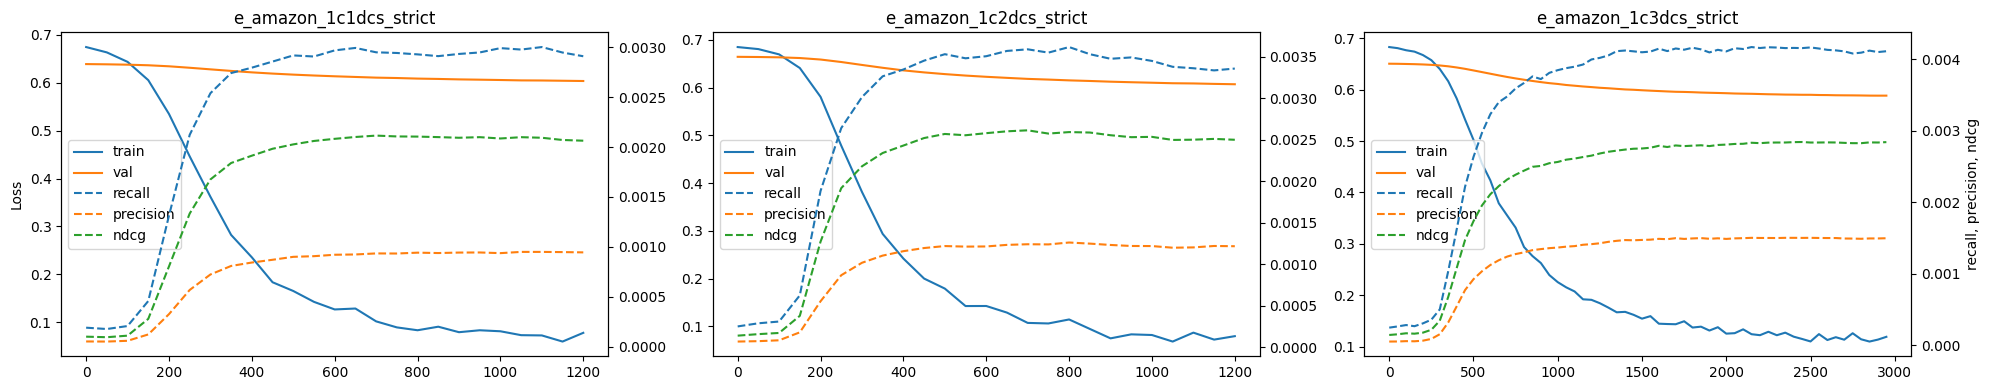

In [54]:
experiments_ran_non_strict = df[df['experiment'].str.contains('_strict') & ~df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(20,4))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(1,total_exp,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')
    
    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

plt.tight_layout()
plt.savefig(version+'loss_metrics_strict.png')
plt.show()


## Losses for non-"Strict" DS and non-Random Runs

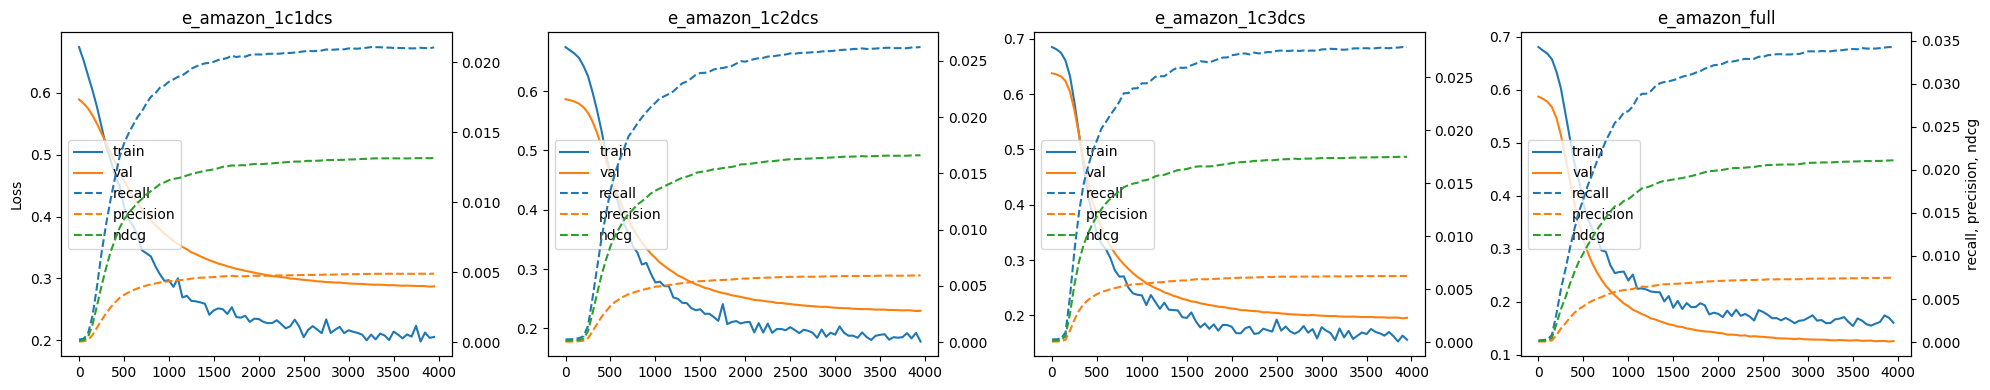

In [55]:
experiments_ran_non_strict = df[~df['experiment'].str.contains('_strict') & ~df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(20,4))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(1,total_exp,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.tight_layout()
plt.savefig(version+'loss_metrics_loose.png')
plt.show()

## Random runs losses for strict runs

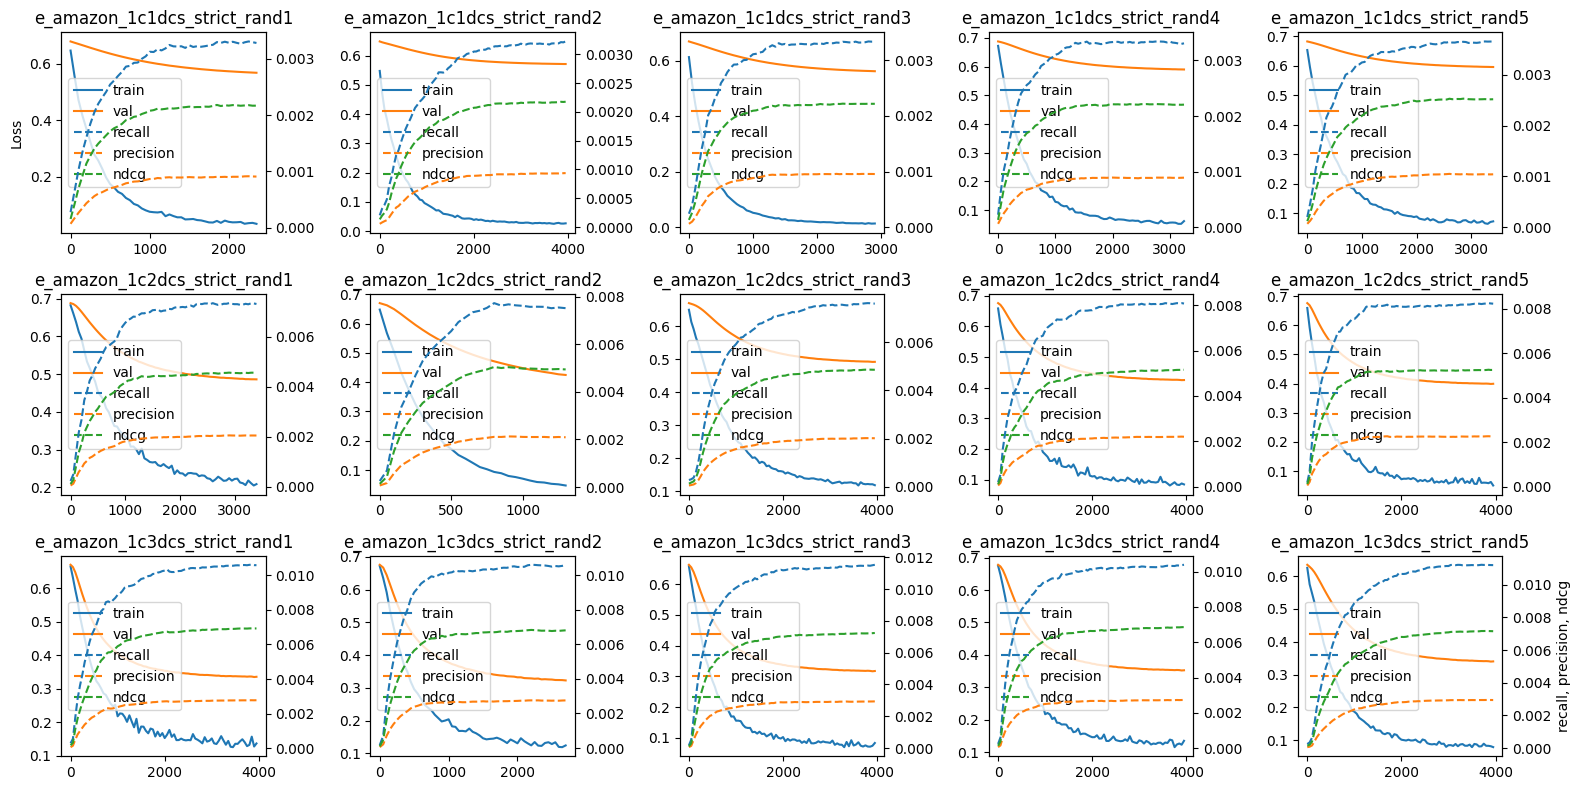

In [56]:
experiments_ran_non_strict = df[df['experiment'].str.contains('_strict') & df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(16,8))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(3,5,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.tight_layout()
plt.savefig(version+'loss_metrics_strict_rand.png')
plt.show()

## Random runs losses for non-strict runs

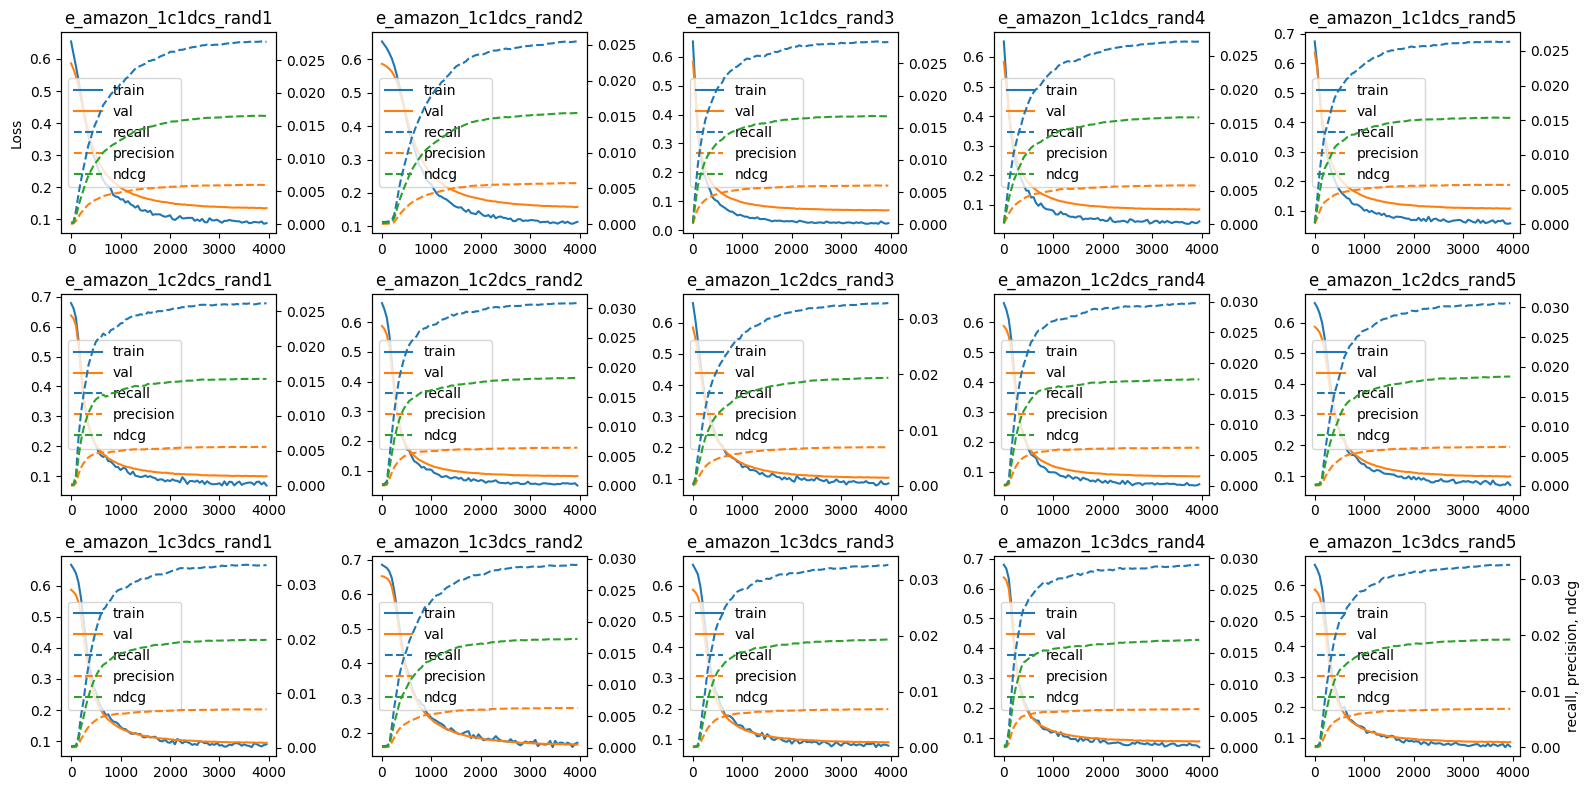

In [57]:
experiments_ran_non_strict = df[~df['experiment'].str.contains('_strict') & df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(16,8))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(3,5,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.tight_layout()
plt.savefig(version+'loss_metrics_loose_rand.png')
plt.show()

## Trial analysis

In [7]:
experiments_ran = df[~df['experiment'].str.contains('_rand')]['experiment']

data =  {}
trials = {}
ranges = ''

objective_metric = df['objective_metric'].unique()[0]
objective_metric = objective_metric if objective_metric is not None else 'recall'
objective_metric_dict = {'recall':0, 'precision':1, 'ndcg':2}

for exp in experiments_ran:
    study = optuna.load_study(study_name=f'Study_{exp}', storage=f'sqlite:///{version}{exp_name}.sqlite3')
    plot_param_importances(study)

    importance = get_param_importances(study, target=lambda t: t.values[objective_metric_dict[objective_metric]]) #added target for multi-objective
    params = {}
    for param, value in importance.items():
        #print(f"{param}: {value}")
        params[param] = value

    ranges = study.get_trials()[0].distributions

    pruned_trials = len(study.get_trials(deepcopy=False, states=[TrialState.PRUNED]))
    complete_trials = len(study.get_trials(deepcopy=False, states=[TrialState.COMPLETE]))

    data[exp] = params
    trials[exp] = {'pruned':pruned_trials, 'complete':complete_trials}

importances_df = pd.DataFrame.from_dict(data, orient='index')
trials_df = pd.DataFrame.from_dict(trials, orient='index')
importances_df

,optimizer,batch_size,lambda_val,lr,embedding_dim,n_layers
e_amazon_1c1dcs,0.795667,0.131297,0.034550,0.025088,0.013048,0.000349
e_amazon_1c1dcs_strict,0.562781,0.017884,0.033819,0.081480,0.081859,0.222178
e_amazon_1c2dcs,0.744779,0.016899,0.183790,0.023668,0.008814,0.022051
e_amazon_1c2dcs_strict,0.662107,0.016060,0.024945,0.040063,0.024129,0.232695
e_amazon_full,0.851828,0.009813,0.035876,0.030086,0.027785,0.044613


In [8]:
studies = optuna.get_all_study_names(storage=f'sqlite:///{version}{exp_name}.sqlite3')

results = {}
for study_name in studies:
    study = optuna.load_study(study_name=study_name, storage=f'sqlite:///{version}{exp_name}.sqlite3')
    is_multi = len(study.directions) > 1

    trials = {}
    for trial in study.get_trials():
        parameters = trial.params
        parameters.update({'status': trial.state})
        parameters.update({'value': trial.values if is_multi else trial.value})
        parameters.update({'multi_objective':is_multi})
        trials[trial.number] = parameters

    results[study_name] = trials

flattened_data = {
    (outer_key, inner_key): values 
    for outer_key, inner_dict in results.items() 
    for inner_key, values in inner_dict.items()
}
flattened_data

trials_params = pd.DataFrame.from_dict(flattened_data, orient='index').reset_index(names=['study','trial'])
trials_params['status'] = trials_params['status'].map({x: str(TrialState(x)).split('.')[1].lower() for x in range(0,5)})
trials_params.head()


,study,trial,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,status,value,multi_objective
0,Study_e_yelp_full,0,1,32,0.000718,0.000001,2889,RMSprop,complete,"[0.033866951729159336, 0.0075091575091575085, ...",True
1,Study_e_yelp_full,1,4,96,0.000110,0.013360,3792,SGD,complete,"[0.0004456780474867326, 0.00010420613868889732...",True
2,Study_e_yelp_full,2,4,64,0.028823,0.006249,2057,RMSprop,complete,"[0.004794606934457264, 0.000975748389541493, 0...",True
3,Study_e_yelp_full,3,3,256,0.002053,0.001557,3244,RMSprop,complete,"[0.008195924957296324, 0.0018362384741695086, ...",True
4,Study_e_yelp_full,4,3,64,0.000634,0.000030,3321,Adam,complete,"[0.024873318178333766, 0.005355563976253632, 0...",True


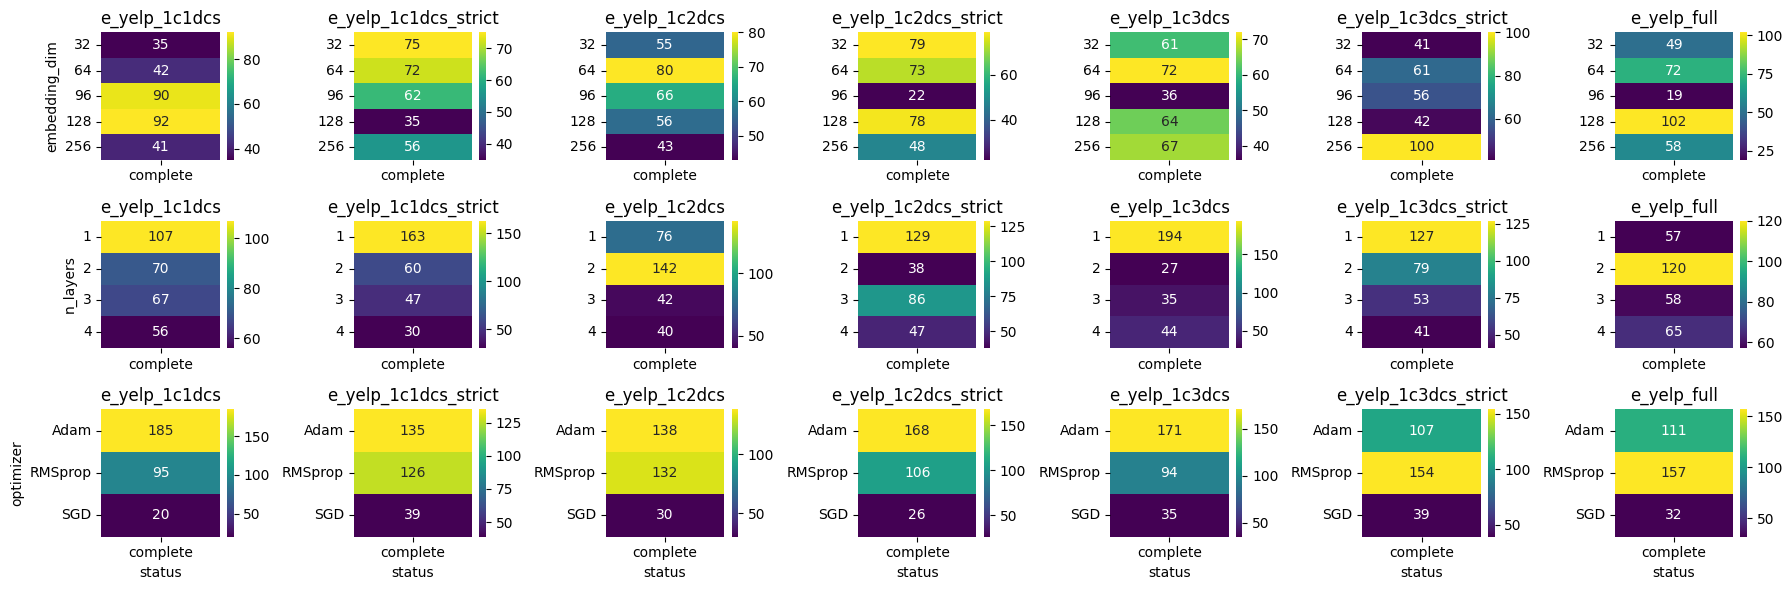

In [9]:
plt.figure(figsize=(18,6))
hyper_params = ['embedding_dim','n_layers','optimizer']

for j,param in enumerate(hyper_params):
    df_t = trials_params.groupby(['study','status',param]).count().reset_index()
    df_t = df_t[~df_t['study'].str.contains('_rand')]

    for i, study in enumerate(df_t['study'].unique()):
        plt.subplot(len(hyper_params),df_t['study'].nunique(),j*(df_t['study'].nunique())+i+1)
        plt.title(study[len('Study_'):])
        sub_df = df_t[df_t['study']==study]
        ax = sns.heatmap(sub_df.pivot(index=param, columns='status', values='trial'), cmap='viridis', annot=True, fmt='.0f')
        plt.yticks(rotation=0)

        if i != 0:
            ax.set(ylabel=None)
        
        if j != len(hyper_params)-1:
            ax.set(xlabel=None)

plt.tight_layout()
plt.savefig(version+'trials_hyperparmeters.png')
plt.show()

In [10]:
study_name = f'Study_{exp_name}_full'

if trials_params['multi_objective'].unique()[0]:
    print('Plotting pareto front ...')
    study = optuna.load_study(study_name=study_name, storage=f'sqlite:///{version}{exp_name}.sqlite3')

    best_trials = study.best_trials
    for trial in best_trials:
        print(f"Trial #{trial.number}: Values={trial.values}, Params={trial.params}")

    fig = plot_pareto_front(study, target_names=["Recall", "Precision","NDCG"])
    fig.update_layout(title=f"3D Pareto Front: {study_name}", width=800, height=800)
    fig.show()
else:
    print('Not a multi-objective run ... ')


Plotting pareto front ...
Trial #246: Values=[0.03683869874776684, 0.007993873942149805, 0.021801980637232682], Params={'n_layers': 1, 'embedding_dim': 128, 'lr': 0.0006340132793158045, 'lambda_val': 2.970506579255523e-05, 'batch_size': 3321, 'optimizer': 'RMSprop'}


In [11]:
ranges

{'n_layers': IntDistribution(high=4, log=False, low=1, step=1),
 'embedding_dim': CategoricalDistribution(choices=(32, 64, 96, 128, 256)),
 'lr': FloatDistribution(high=0.1, log=True, low=1e-05, step=None),
 'lambda_val': FloatDistribution(high=0.1, log=True, low=1e-06, step=None),
 'batch_size': IntDistribution(high=4096, log=False, low=512, step=1),
 'optimizer': CategoricalDistribution(choices=('Adam', 'RMSprop', 'SGD'))}

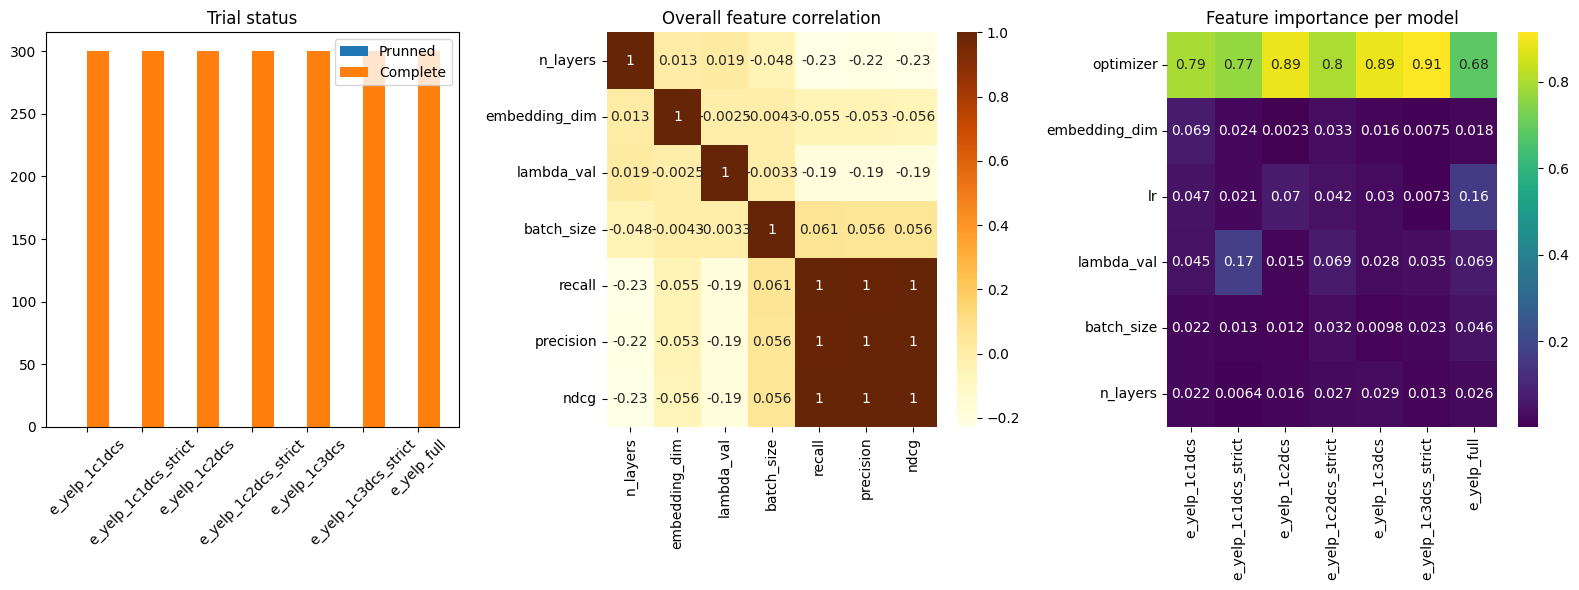

In [12]:
x = np.arange(len(trials_df))
width = 0.4

plt.figure(figsize=(16,6))
plt.subplot(1,3,1)
plt.bar(x = x, width = width, height=trials_df['pruned'], label='Prunned')
plt.bar(x = x+width, width = width, height=trials_df['complete'], label='Complete')

plt.legend()
plt.xticks(x+width/2, trials_df.index, rotation=45)

plt.title('Trial status')

plt.subplot(1,3,2)
if trials_params['multi_objective'].unique()[0]:
    sns.heatmap(trials_params.assign(recall=trials_params['value'].apply(pd.Series)[0], precision=trials_params['value'].apply(pd.Series)[1], ndcg=trials_params['value'].apply(pd.Series)[2])[['n_layers','embedding_dim','lambda_val','batch_size','recall','precision','ndcg']].corr(), cmap='YlOrBr', annot=True)
    plt.title('Overall feature correlation')
else:
    sns.heatmap(trials_params[['n_layers','embedding_dim','lambda_val','batch_size','value']].corr(), cmap='YlOrBr', annot=True)
    plt.title('Overall feature correlation')

plt.subplot(1,3,3)
sns.heatmap(importances_df.T, annot=True, cmap='viridis')
plt.title('Feature importance per model')

plt.tight_layout()
plt.savefig(version+'trials_feature_importance.png')
plt.show()

## Visualizations

In [58]:
key = ['experiment']
val_features = ['val_loss','val_recall','val_precision','val_ndcg' ]
test_features = ['test_loss','test_recall','test_precision','test_ndcg']
train_features = ['best_recall','cycle','early_stopping'] if "best_recall" in df.columns else []
time_features = ['optim_time','train_time','infer_time'] + (['ds_time'] if "ds_time" in df.columns else [])
edge_features =  ['train_edges','ds_users', 'ds_items']
numerical_features = val_features + test_features + train_features 
categorical_features = ['n_layers','embedding_dim','lr','lambda_val','batch_size', 'optimizer']

cleanup_columns = ['ds_time','ds_users','ds_items']
for col in cleanup_columns:
    if col not in df:
        df[col] = np.nan

random_experiments_stats = df.copy()
random_experiments_stats = random_experiments_stats[key + numerical_features + time_features + edge_features + categorical_features]
random_experiments_stats['experiment'] = random_experiments_stats['experiment'].apply(lambda x: x[len(exp_name)+1:-1] if '_rand' in x else x[len(exp_name)+1:])
color_dict = { exp:color_map[exp[0:4]] for exp in random_experiments_stats['experiment'].unique()}
random_experiments_stats.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,best_recall,cycle,early_stopping,optim_time,train_time,infer_time,ds_time,train_edges,ds_users,ds_items,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer
7,1c1dcs,0.287298,0.021021,0.004900,0.013154,0.286990,0.021771,0.005027,0.013862,0.021051,3950,False,62454.348099,378.595296,7.326218,77762.739275,858585,4799.0,14262.0,1,256,0.000779,0.000456,2278,RMSprop
8,1c1dcs_rand,0.135574,0.027803,0.005997,0.016519,0.134786,0.028050,0.006060,0.016792,0.027787,3950,False,74163.987983,369.643595,7.338904,NaN,858585,NaN,NaN,1,256,0.001433,0.000152,3960,RMSprop
9,1c1dcs_rand,0.158726,0.025483,0.005739,0.015524,0.158071,0.026709,0.005893,0.016268,0.025494,3950,False,63471.853679,372.606793,7.358322,NaN,858585,NaN,NaN,1,256,0.001393,0.000006,4003,Adam
10,1c1dcs_rand,0.069087,0.028391,0.006006,0.016822,0.068399,0.027787,0.005997,0.016637,0.028386,3600,False,71922.684100,370.931501,7.443765,NaN,858585,NaN,NaN,1,256,0.002826,0.000001,3907,RMSprop
11,1c1dcs_rand,0.084690,0.027103,0.005753,0.015860,0.084382,0.027458,0.005969,0.016403,0.027118,3550,False,71988.440058,368.026323,7.694551,NaN,858585,NaN,NaN,1,256,0.002852,0.000015,2231,RMSprop


In [59]:
total_run = random_experiments_stats[time_features].sum().sum()
elapsed_exp = random_experiments_stats.shape[0]
print('Total elapsed time: ', str(datetime.timedelta(seconds=total_run)))
print('ETC: ', str(datetime.timedelta(seconds=total_run/elapsed_exp*37 - total_run)))

Total elapsed time:  30 days, 22:28:50.783141
ETC:  0:00:00


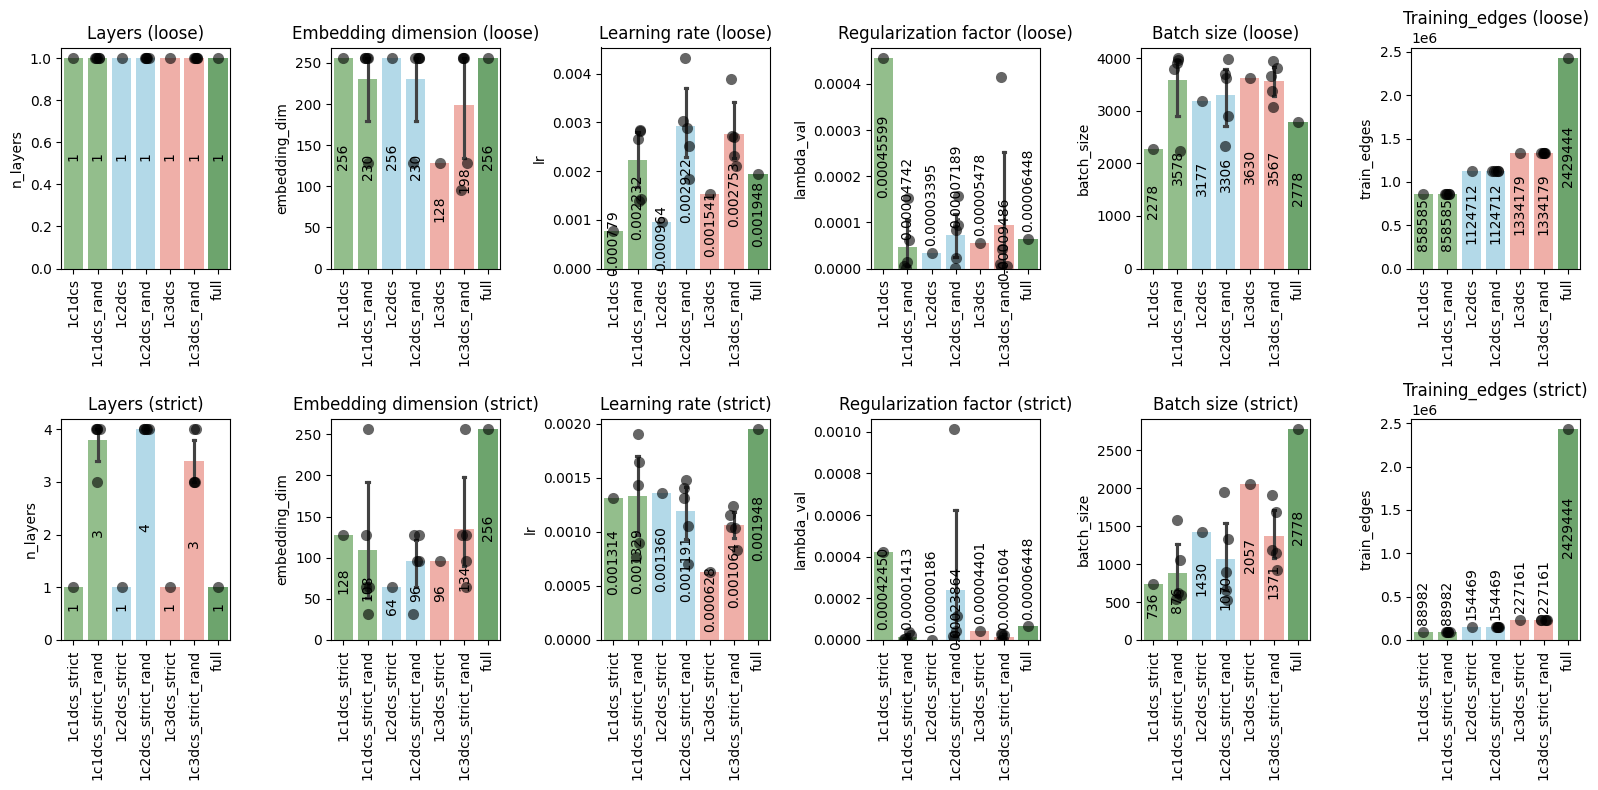

In [60]:
plots=['n_layers','embedding_dim','lr', 'lambda_val', 'batch_size','train_edges']
titles=['Layers', 'Embedding dimension', 'Learning rate', 'Regularization factor', 'Batch size','Training_edges']
formats=['%d', '%d', '%.6f', '%.8f', '%d', '%d']

n_plots_height = 2
n_plots_wide = len(plots)

plt.figure(figsize=(16,8))

cols = ['n_layers','embedding_dim','lr','batch_size']

for j,strict in enumerate([False, True]):
    for i,metric in enumerate(plots):
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment'].str.contains('_strict') == strict) | random_experiments_stats['experiment'].str.contains('full')]
        ax = sns.barplot(data = subset_df, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)

        sns.stripplot(data=subset_df, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
        plt.title(titles[i]+(' (strict)' if strict else ' (loose)'))
        plt.xlabel('')
        plt.xticks(rotation=90)


plt.tight_layout()
plt.savefig(version+'experiments_hyperparmeters.png')
plt.show()

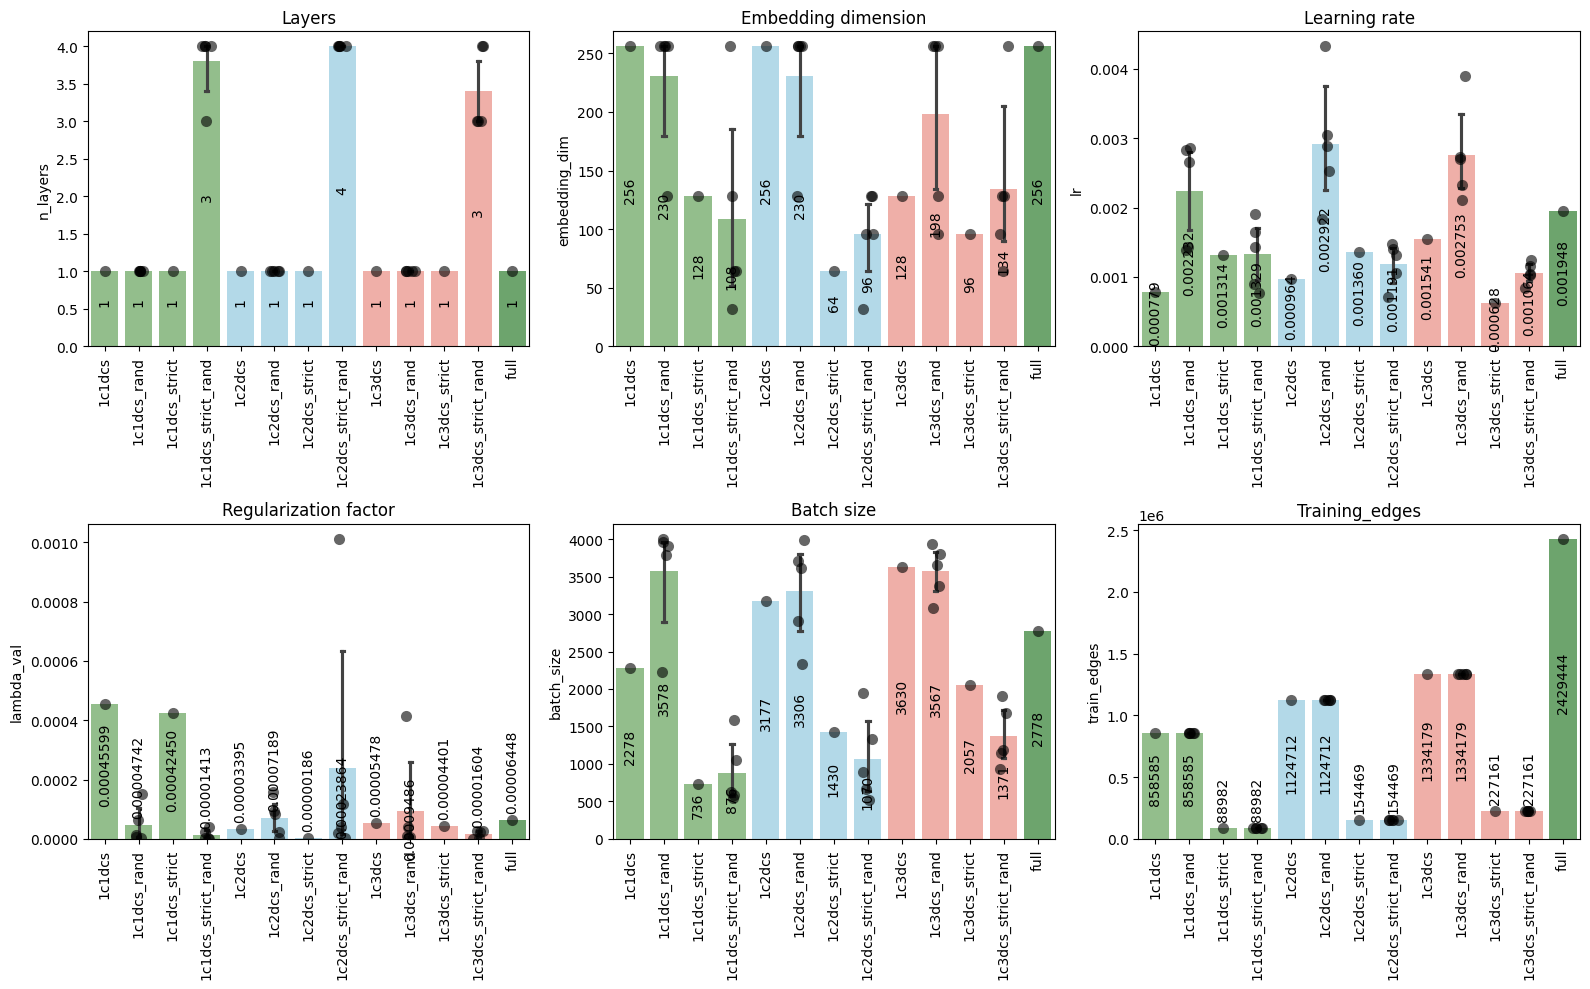

In [61]:

new_df = df.copy()
new_df['experiment'] = new_df['experiment'].apply(lambda x: x[len(exp_name)+1:])

plots=['n_layers','embedding_dim','lr', 'lambda_val', 'batch_size','train_edges']
titles=['Layers', 'Embedding dimension', 'Learning rate', 'Regularization factor', 'Batch size','Training_edges']
formats=['%d', '%d', '%.6f', '%.8f', '%d', '%d']

n_plots_height = 2
n_plots_wide = len(plots)//n_plots_height if (len(plots)/n_plots_height) % 2 ==1 else len(plots)//n_plots_height

plt.figure(figsize=(16,10))

cols = ['n_layers','embedding_dim','lr','batch_size']

for i,metric in enumerate(plots):
    plt.subplot(n_plots_height,n_plots_wide,i+1)

    ax = sns.barplot(data = random_experiments_stats, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)
    max_value = np.max([ x.datavalues for x in ax.containers])
    for container in ax.containers:
        ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
    sns.stripplot(data=random_experiments_stats, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
    plt.title(titles[i])
    plt.xlabel('')
    plt.xticks(rotation=90)

plt.tight_layout()
#plt.savefig(version+'experiments_hyperparmeters.png')
plt.show()


In [62]:
aggregations = { x : ['mean','std'] for x in numerical_features + time_features}
aggregations.update({ x : ['mean'] for x in edge_features} )
aggregations.update({ x : ['unique'] for x in categorical_features} )


result = random_experiments_stats.groupby(key, as_index=False).agg(aggregations)
result.columns = ["_".join(col).strip() for col in result.columns.values]
result.columns = [ x[:-1] if x[-1]== '_' else x for x in result.columns]
result.fillna(0, inplace=True)
result.head()

,experiment,val_loss_mean,val_loss_std,val_recall_mean,val_recall_std,val_precision_mean,val_precision_std,val_ndcg_mean,val_ndcg_std,test_loss_mean,test_loss_std,test_recall_mean,test_recall_std,test_precision_mean,test_precision_std,test_ndcg_mean,test_ndcg_std,best_recall_mean,best_recall_std,cycle_mean,cycle_std,early_stopping_mean,early_stopping_std,optim_time_mean,optim_time_std,train_time_mean,train_time_std,infer_time_mean,infer_time_std,ds_time_mean,ds_time_std,train_edges_mean,ds_users_mean,ds_items_mean,n_layers_unique,embedding_dim_unique,lr_unique,lambda_val_unique,batch_size_unique,optimizer_unique
0,1c1dcs,0.287298,0.000000,0.021021,0.000000,0.004900,0.000000,0.013154,0.000000,0.286990,0.000000,0.021771,0.000000,0.005027,0.000000,0.013862,0.000000,0.021051,0.000000,3950.0,0.000000,0.0,0.000000,62454.348099,0.00000,378.595296,0.00000,7.326218,0.000000,77762.739275,0.0,858585.0,4799.0,14262.0,[1],[256],[0.0007787505453018097],[0.00045598605516994004],[2278],[RMSprop]
1,1c1dcs_rand,0.111433,0.036515,0.027019,0.001157,0.005836,0.000154,0.016019,0.000629,0.110784,0.036441,0.027348,0.000609,0.005948,0.000093,0.016405,0.000337,0.027023,0.001148,3740.0,194.935887,0.0,0.000000,69970.082938,4197.61566,362.948540,16.52879,7.418829,0.167605,0.000000,0.0,858585.0,0.0,0.0,[1],"[256, 128]","[0.0014333316079584322, 0.0013930224389611008,...","[0.00015236573767345014, 5.842035456079482e-06...","[3960, 4003, 3907, 2231, 3792]","[RMSprop, Adam]"
2,1c1dcs_strict,0.603498,0.000000,0.002909,0.000000,0.000945,0.000000,0.002063,0.000000,0.603807,0.000000,0.002861,0.000000,0.000890,0.000000,0.001908,0.000000,0.002948,0.000000,700.0,0.000000,1.0,0.000000,26108.437105,0.00000,95.454886,0.00000,6.942806,0.000000,77762.739275,0.0,88982.0,4799.0,14262.0,[1],[128],[0.0013135077251507194],[0.0004244982241785935],[736],[Adam]
3,1c1dcs_strict_rand,0.577360,0.014188,0.003361,0.000171,0.000947,0.000059,0.002257,0.000149,0.577633,0.014264,0.003395,0.000297,0.000934,0.000071,0.002254,0.000200,0.003368,0.000163,2770.0,773.466224,0.8,0.447214,45577.094056,4483.06437,271.263283,83.15684,7.004978,0.153700,0.000000,0.0,88982.0,0.0,0.0,"[3, 4]","[64, 256, 128, 32]","[0.0019032891633152442, 0.000769747194462119, ...","[3.9206514264817366e-05, 4.2886606921314005e-0...","[620, 591, 1581, 1051, 539]",[RMSprop]
4,1c2dcs,0.230044,0.000000,0.026213,0.000000,0.005932,0.000000,0.016603,0.000000,0.229479,0.000000,0.026578,0.000000,0.006073,0.000000,0.016701,0.000000,0.026215,0.000000,3950.0,0.000000,0.0,0.000000,70909.005422,0.00000,389.398903,0.00000,7.383584,0.000000,74149.689386,0.0,1124712.0,6839.0,15365.0,[1],[256],[0.0009639120449834559],[3.395229420030629e-05],[3177],[Adam]


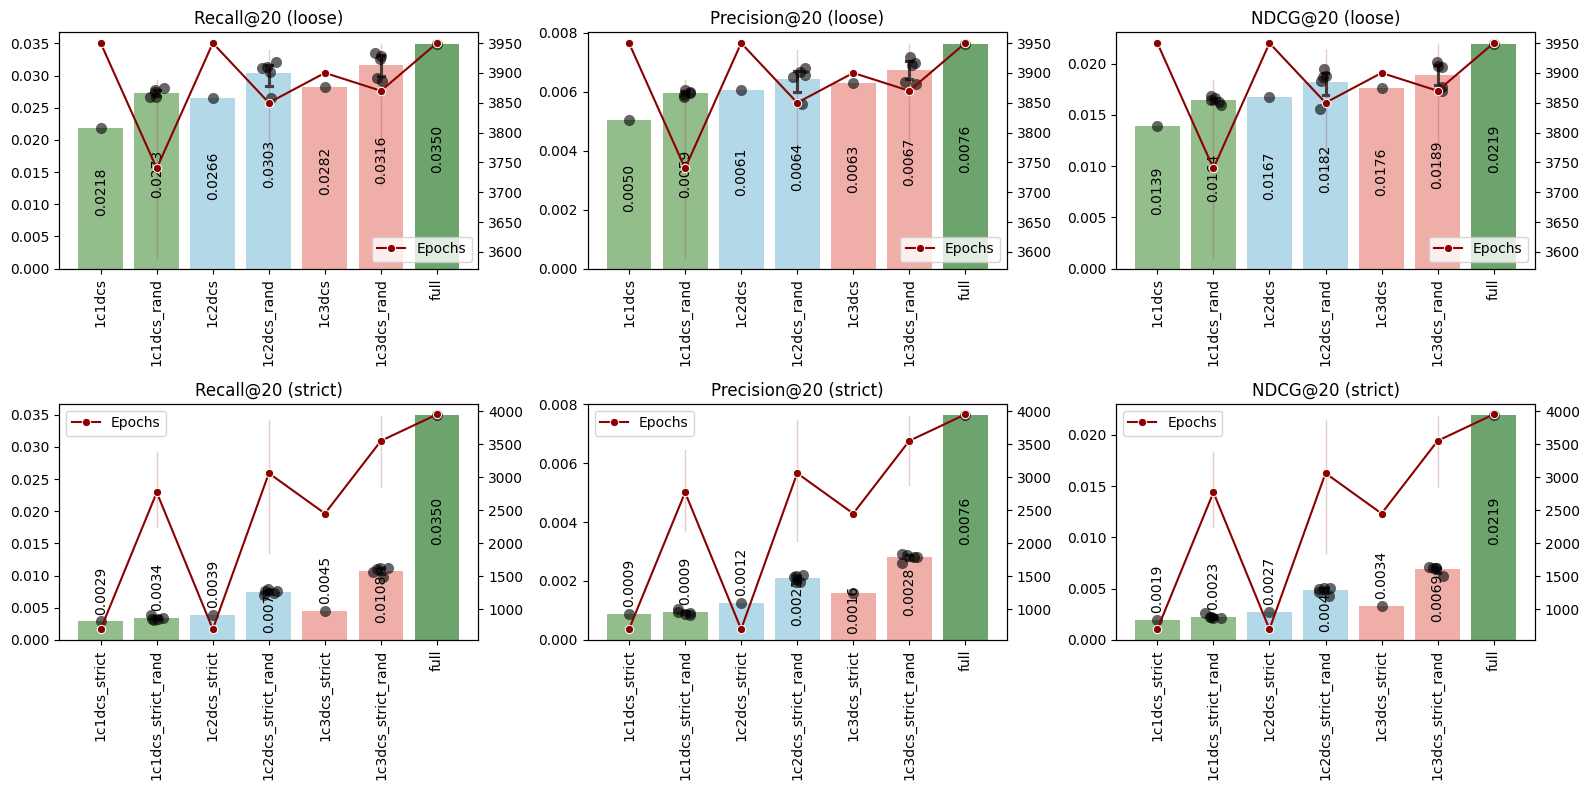

In [63]:
plots=['test_recall','test_precision','test_ndcg']
titles=['Recall@20', 'Precision@20', 'NDCG@20']
formats=['%.4f', '%.4f', '%.4f']


n_plots_height = 2
n_plots_wide = len(plots)

plt.figure(figsize=(16,8))
#plt.figure(figsize=(20,5))

for j,strict in enumerate([False, True]):

    for i,metric in enumerate(plots):
        #plt.subplot(1,len(plots),i+1)
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment'].str.contains('_strict') == strict) | random_experiments_stats['experiment'].str.contains('full')]
        
        ax = sns.barplot(data = subset_df, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
        sns.stripplot(data=subset_df, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
        plt.ylabel('')
        plt.xlabel('')
        plt.xticks(rotation=90)

        ax2 = ax.twinx()
        #sns.lineplot(data = random_experiments_stats, x='experiment', ax=ax2, y='cycle', errorbar=('ci', 95), alpha=0.7,  hue='experiment', legend=False)
        if 'cycle' in subset_df.columns:
            sns.lineplot(data=subset_df, x='experiment', y='cycle', color='darkred', errorbar="ci", marker='o', ax=ax2, sort=False, label='Epochs')
            ax2.set_ylabel('Training epochs')

        plt.title(titles[i]+(' (strict)' if strict else ' (loose)'))
        plt.xlabel('')
        plt.ylabel('')
        plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(version+'experiments_metrics.png')
plt.show()

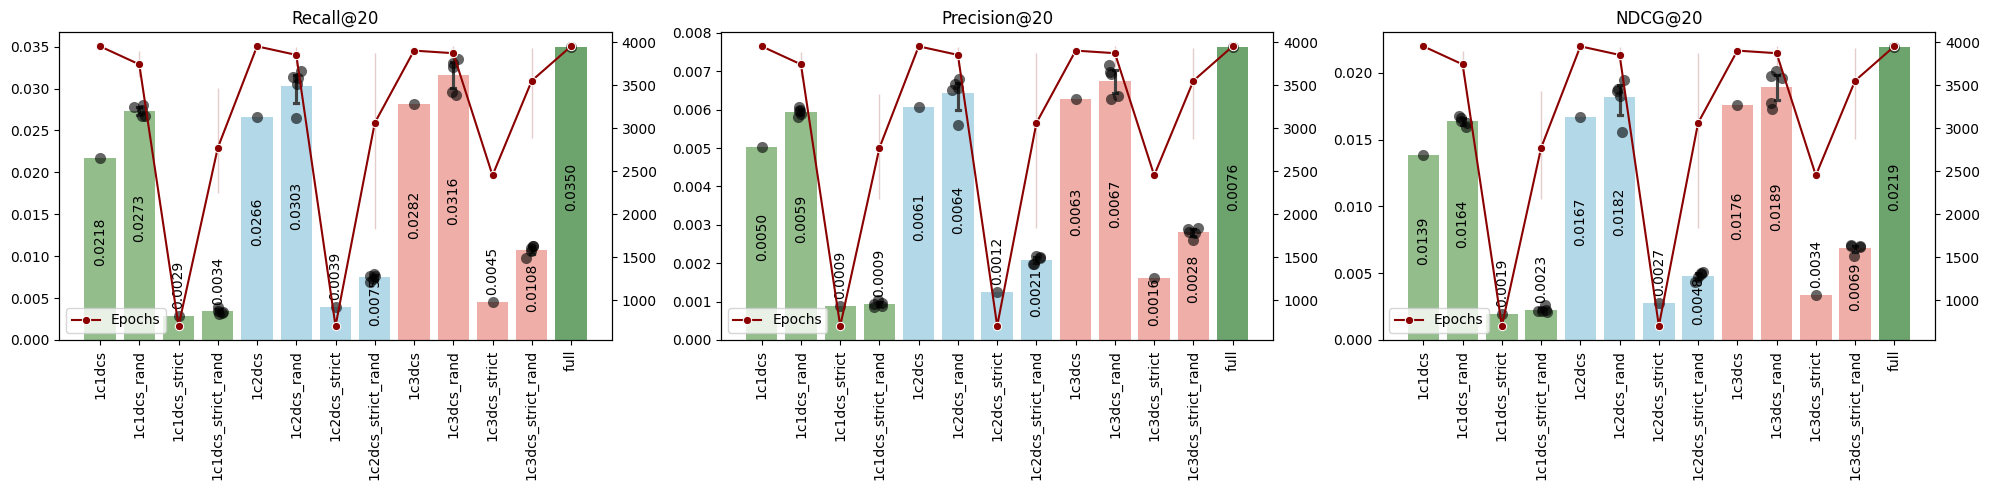

In [64]:
plots=['test_recall','test_precision','test_ndcg']
titles=['Recall@20', 'Precision@20', 'NDCG@20']
formats=['%.4f', '%.4f', '%.4f']

plt.figure(figsize=(20,5))

for i,metric in enumerate(plots):
    plt.subplot(1,len(plots),i+1)
    
    ax = sns.barplot(data = random_experiments_stats, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)
    max_value = np.max([ x.datavalues for x in ax.containers])
    for container in ax.containers:
        ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
    sns.stripplot(data=random_experiments_stats, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
    plt.ylabel('')
    plt.xlabel('')
    plt.xticks(rotation=90)

    ax2 = ax.twinx()
    #sns.lineplot(data = random_experiments_stats, x='experiment', ax=ax2, y='cycle', errorbar=('ci', 95), alpha=0.7,  hue='experiment', legend=False)
    if 'cycle' in random_experiments_stats.columns:
        sns.lineplot(data=random_experiments_stats, x='experiment', y='cycle', color='darkred', errorbar="ci", marker='o', ax=ax2, sort=False, label='Epochs')
        ax2.set_ylabel('Training epochs')

    plt.title(titles[i])
    plt.xlabel('')
    plt.ylabel('')
    plt.xticks(rotation=90)

plt.tight_layout()
#plt.savefig(version+'experiments_metrics.png')
plt.show()

<Figure size 1600x1000 with 0 Axes>

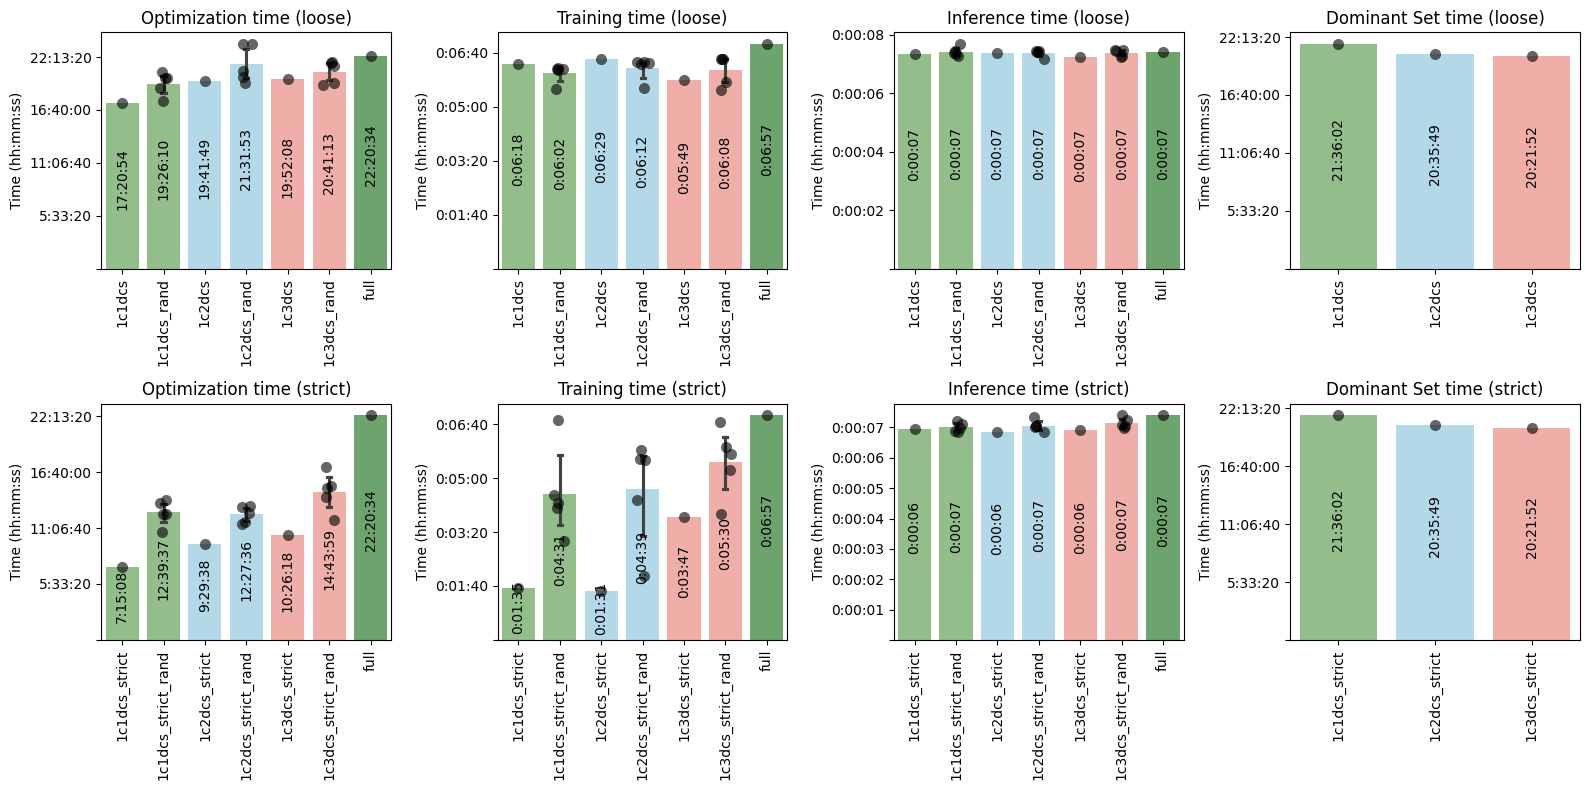

In [65]:
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plots=time_features #['optim_time','train_time','infer_time'] + ['ds_time'] if 'ds_time' in random_experiments_stats.columns else []
titles=['Optimization time', 'Training time', 'Inference time','Dominant Set time']
# formats=['%d', '%d', '%.4f', '%d', '%d']
colors=[ '#4CAF50','#4CAF50','skyblue','skyblue','salmon','salmon', 'forestgreen']

plt.figure(figsize=(16,10))
n_plots_height = 2
n_plots_wide = len(plots)//n_plots_height if (len(plots)/n_plots_height) % 2 ==1 else len(plots)//n_plots_height

# Added a default value to pos (pos=None) so we can reuse this function for bar labels easily
def format_time(x, pos=None):
    if pd.isna(x) or x <= 0:
        return ""
    if x >= 1:
        value = str(timedelta(seconds=int(x)))
    else:
        m, s = divmod(x, 60)
        value = f"{int(m):02d}:{s:06.3f}"
    return value


n_plots_height = 2
n_plots_wide = len(plots)

plt.figure(figsize=(16,8))
#plt.figure(figsize=(20,5))

for j,strict in enumerate([False, True]):
    for i, metric in enumerate(plots):
        #plt.subplot(n_plots_height, n_plots_wide, i+1)
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment'].str.contains('_strict') == strict) | random_experiments_stats['experiment'].str.contains('full')]

        # Create the barplot
        ax = sns.barplot(
            data=subset_df[subset_df[metric]>0], 
            x='experiment', 
            y=metric, 
            errorbar=('ci', 95),
            capsize=0.1, 
            alpha=0.7, 
            palette=color_dict,  
            hue='experiment', 
            legend=False
        ) 

        # --- FIX FOR BAR LABELS ---
        # Iterate through all containers generated by Seaborn's hue
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            # Generate a label list directly from the bar heights in this specific container
            labels = [format_time(val) for val in container.datavalues]
            ax.bar_label(container, labels=labels, label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
        # --------------------------


        # Add the stripplot
        sns.stripplot(
            data=subset_df[subset_df[metric]>0], 
            x='experiment', 
            y=metric, 
            color='black', 
            size=8, 
            alpha=0.6, 
            jitter=0.15,
            ax=ax
        )
        
        plt.title(titles[i]+(' (strict)' if strict else ' (loose)'))
        plt.xlabel('')
        plt.xticks(rotation=90)

        # Use the mean of the actual current metric to decide the axis label
        current_mean = subset_df[metric].mean()
        if current_mean < 1:
            plt.ylabel('Time (mm:ss.ms)')
        else:
            plt.ylabel('Time (hh:mm:ss)')
            
        plt.gca().yaxis.set_major_formatter(FuncFormatter(format_time))

plt.tight_layout()
plt.savefig(version+'experiments_times.png')
plt.show()

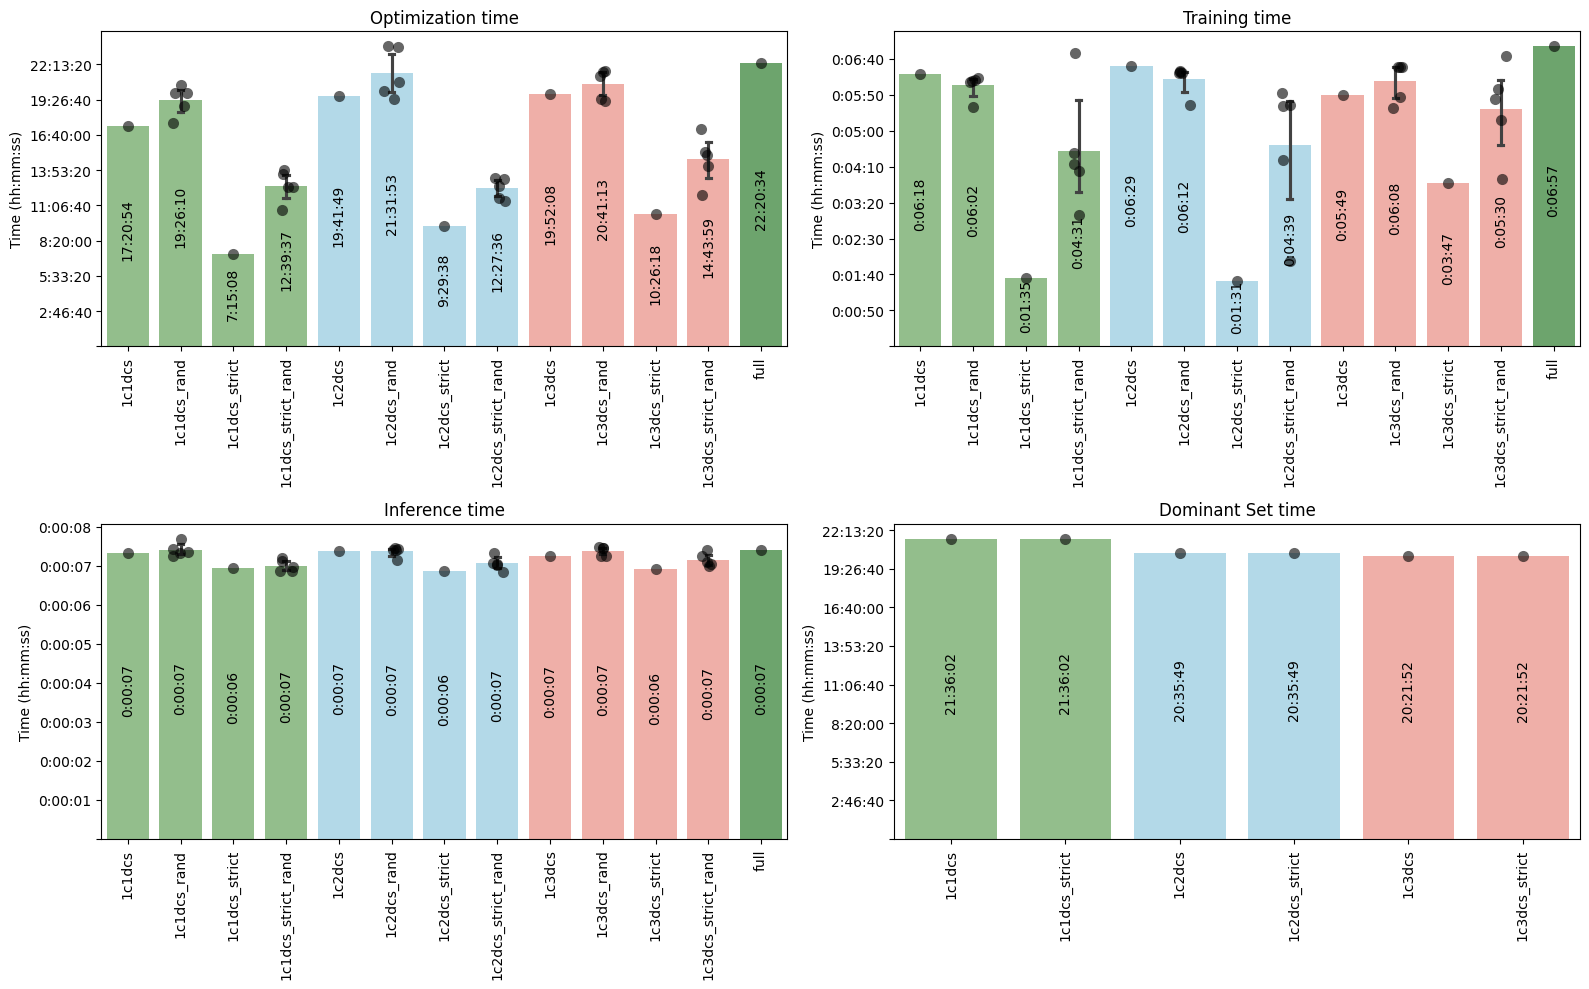

In [66]:
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plots=time_features #['optim_time','train_time','infer_time'] + ['ds_time'] if 'ds_time' in random_experiments_stats.columns else []
titles=['Optimization time', 'Training time', 'Inference time','Dominant Set time']
# formats=['%d', '%d', '%.4f', '%d', '%d']
colors=[ '#4CAF50','#4CAF50','skyblue','skyblue','salmon','salmon', 'forestgreen']

plt.figure(figsize=(16,10))
n_plots_height = 2
n_plots_wide = len(plots)//n_plots_height if (len(plots)/n_plots_height) % 2 ==1 else len(plots)//n_plots_height

# Added a default value to pos (pos=None) so we can reuse this function for bar labels easily
def format_time(x, pos=None):
    if pd.isna(x) or x <= 0:
        return ""
    if x >= 1:
        value = str(timedelta(seconds=int(x)))
    else:
        m, s = divmod(x, 60)
        value = f"{int(m):02d}:{s:06.3f}"
    return value

for i, metric in enumerate(plots):
    plt.subplot(n_plots_height, n_plots_wide, i+1)

    # Create the barplot
    ax = sns.barplot(
        data=random_experiments_stats[random_experiments_stats[metric]>0], 
        x='experiment', 
        y=metric, 
        errorbar=('ci', 95),
        capsize=0.1, 
        alpha=0.7, 
        palette=color_dict,  
        hue='experiment', 
        legend=False
    ) 

    # --- FIX FOR BAR LABELS ---
    # Iterate through all containers generated by Seaborn's hue
    max_value = np.max([ x.datavalues for x in ax.containers])
    for container in ax.containers:
        # Generate a label list directly from the bar heights in this specific container
        labels = [format_time(val) for val in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
    # --------------------------


    # Add the stripplot
    sns.stripplot(
        data=random_experiments_stats[random_experiments_stats[metric]>0], 
        x='experiment', 
        y=metric, 
        color='black', 
        size=8, 
        alpha=0.6, 
        jitter=0.15,
        ax=ax
    )
    
    plt.title(titles[i])
    plt.xlabel('')
    plt.xticks(rotation=90)

    # Use the mean of the actual current metric to decide the axis label
    current_mean = random_experiments_stats[metric].mean()
    if current_mean < 1:
        plt.ylabel('Time (mm:ss.ms)')
    else:
        plt.ylabel('Time (hh:mm:ss)')
        
    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_time))

plt.tight_layout()
#plt.savefig(version+'experiments_times.png')
plt.show()

In [67]:
result_viewable = result.copy()

for col in numerical_features:
    result_viewable[col] = result_viewable[[col+'_mean',col+'_std']].apply(lambda x: '{:,.4f}'.format(x[col+'_mean']) if x[col+'_std'] ==0 else '{:,.4f}'.format(x[col+'_mean']) + ' \u00B1 ' +  '{:,.4f}'.format(x[col+'_std']), axis=1)
    result_viewable.drop([col+'_mean', col+'_std'], axis=1, inplace=True)

for col in time_features:
    result_viewable[col] = result_viewable[[col+'_mean',col+'_std']].apply(lambda x: str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_mean']))) if x[col+'_std'] ==0 else str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_mean']))) + ' \u00B1 ' +  str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_std']))), axis=1)
    result_viewable.drop([col+'_mean', col+'_std'], axis=1, inplace=True)

result_viewable = result_viewable[key + numerical_features + [x +'_mean' for x in edge_features] + time_features + [x +'_unique' for x in categorical_features] ]


for token in ['_unique','_mean']:
    rename_dict = { x : x[:-len(token)] if token in x else x for x in result_viewable.columns }
    result_viewable.rename(rename_dict, axis=1, inplace=True)


In [68]:
result_viewable

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,best_recall,cycle,early_stopping,train_edges,ds_users,ds_items,optim_time,train_time,infer_time,ds_time,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer
0,1c1dcs,0.2873,0.0210,0.0049,0.0132,0.2870,0.0218,0.0050,0.0139,0.0211,"3,950.0000",0.0000,858585.0,4799.0,14262.0,17:20:54,00:06:18,00:00:07,21:36:02,[1],[256],[0.0007787505453018097],[0.00045598605516994004],[2278],[RMSprop]
1,1c1dcs_rand,0.1114 ± 0.0365,0.0270 ± 0.0012,0.0058 ± 0.0002,0.0160 ± 0.0006,0.1108 ± 0.0364,0.0273 ± 0.0006,0.0059 ± 0.0001,0.0164 ± 0.0003,0.0270 ± 0.0011,"3,740.0000 ± 194.9359",0.0000,858585.0,0.0,0.0,19:26:10 ± 01:09:57,00:06:02 ± 00:00:16,00:00:07 ± 00:00:00,00:00:00,[1],"[256, 128]","[0.0014333316079584322, 0.0013930224389611008,...","[0.00015236573767345014, 5.842035456079482e-06...","[3960, 4003, 3907, 2231, 3792]","[RMSprop, Adam]"
2,1c1dcs_strict,0.6035,0.0029,0.0009,0.0021,0.6038,0.0029,0.0009,0.0019,0.0029,700.0000,1.0000,88982.0,4799.0,14262.0,07:15:08,00:01:35,00:00:06,21:36:02,[1],[128],[0.0013135077251507194],[0.0004244982241785935],[736],[Adam]
3,1c1dcs_strict_rand,0.5774 ± 0.0142,0.0034 ± 0.0002,0.0009 ± 0.0001,0.0023 ± 0.0001,0.5776 ± 0.0143,0.0034 ± 0.0003,0.0009 ± 0.0001,0.0023 ± 0.0002,0.0034 ± 0.0002,"2,770.0000 ± 773.4662",0.8000 ± 0.4472,88982.0,0.0,0.0,12:39:37 ± 01:14:43,00:04:31 ± 00:01:23,00:00:07 ± 00:00:00,00:00:00,"[3, 4]","[64, 256, 128, 32]","[0.0019032891633152442, 0.000769747194462119, ...","[3.9206514264817366e-05, 4.2886606921314005e-0...","[620, 591, 1581, 1051, 539]",[RMSprop]
4,1c2dcs,0.2300,0.0262,0.0059,0.0166,0.2295,0.0266,0.0061,0.0167,0.0262,"3,950.0000",0.0000,1124712.0,6839.0,15365.0,19:41:49,00:06:29,00:00:07,20:35:49,[1],[256],[0.0009639120449834559],[3.395229420030629e-05],[3177],[Adam]
5,1c2dcs_rand,0.0942 ± 0.0097,0.0300 ± 0.0024,0.0063 ± 0.0005,0.0177 ± 0.0015,0.0934 ± 0.0096,0.0303 ± 0.0022,0.0064 ± 0.0005,0.0182 ± 0.0015,0.0300 ± 0.0025,"3,850.0000 ± 145.7738",0.0000,1124712.0,0.0,0.0,21:31:53 ± 01:57:17,00:06:12 ± 00:00:20,00:00:07 ± 00:00:00,00:00:00,[1],"[128, 256]","[0.00432269493085368, 0.002891681999083074, 0....","[8.31137517090784e-05, 9.532064558692847e-05, ...","[2327, 3984, 3614, 3702, 2903]","[Adam, RMSprop]"
6,1c2dcs_strict,0.6072,0.0034,0.0012,0.0025,0.6078,0.0039,0.0012,0.0027,0.0036,700.0000,1.0000,154469.0,6839.0,15365.0,09:29:38,00:01:31,00:00:06,20:35:49,[1],[64],[0.0013601909806526136],[1.8566194585261947e-06],[1430],[Adam]
7,1c2dcs_strict_rand,0.4457 ± 0.0412,0.0078 ± 0.0004,0.0021 ± 0.0001,0.0050 ± 0.0003,0.4457 ± 0.0416,0.0075 ± 0.0004,0.0021 ± 0.0001,0.0048 ± 0.0003,0.0078 ± 0.0004,"3,060.0000 ± 1,331.0710",0.4000 ± 0.5477,154469.0,0.0,0.0,12:27:36 ± 00:50:13,00:04:39 ± 00:01:37,00:00:07 ± 00:00:00,00:00:00,[4],"[32, 128, 96]","[0.0013152005063538942, 0.001054000957924945, ...","[0.0010119023152848768, 2.881916161422813e-06,...","[891, 1950, 1329, 520, 664]",[RMSprop]
8,1c3dcs,0.1964,0.0279,0.0063,0.0175,0.1956,0.0282,0.0063,0.0176,0.0278,"3,900.0000",0.0000,1334179.0,9137.0,16873.0,19:52:08,00:05:49,00:00:07,20:21:52,[1],[128],[0.0015408940244593466],[5.477590626257637e-05],[3630],[Adam]
9,1c3dcs_rand,0.1058 ± 0.0342,0.0314 ± 0.0022,0.0066 ± 0.0004,0.0185 ± 0.0013,0.1050 ± 0.0340,0.0316 ± 0.0020,0.0067 ± 0.0004,0.0189 ± 0.0013,0.0314 ± 0.0022,"3,870.0000 ± 178.8854",0.0000,1334179.0,0.0,0.0,20:41:13 ± 01:10:56,00:06:08 ± 00:00:27,00:00:07 ± 00:00:00,00:00:00,[1],"[256, 96, 128]","[0.002321472096698613, 0.0021147498954259742, ...","[4.1683544914493574e-05, 0.0004146784682622004...","[3804, 3937, 3074, 3654, 3370]",[Adam]


# Conclusions and actions

## Symptoms
- Model is overfitting, given the train vs. val losses tracking (don't know about the performance metrics, since they haven't been captured.)
- Full graph is converging too fast, but train/val curves are  too far apart, system may have learned "too" quickly

## Suggested actions
- Add tracking for Recall, precision and NDCG (already did after current run.)
- Verify the random sample methods, since it only randomizes using train_test_split from sklearn, but sets may not be fully-connected or even coherent -> Rolando said this before.
    - Nos llevamos aristas siempre que embos nodos esten representados.
- After the right random sample calculate the dominant set from the sample set. --> from here sample random or structure preserving random.
    - The 5 random runs (absolute random), should sample from the random sample ONLY and maybe use a similar algorithm as the full random sample method, 
        - or maybe sample from the main sample with some other variation, limiting the total amount of rows
- Reduce the seach space for certain parameters (embedding_dim, remove the 32 option for instance, layers remove the 4 layers options) --> **Run 300 instances.**
    - Had done this before, but because of th randomization, we may have gotten a bad batch and seems to not converge.




In [ ]:
#import optuna

# Delete an entire study from the SQLite file
#optuna.delete_study(
#    study_name="Study_e_yelp_1c1dcs_rand3", 
#    storage="sqlite:///e_yelp.sqlite3"
#)


/home/paco/gnn-ds/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
exp_name = 'e_yelp'
version=f'historic_results/{exp_name}/pass_0/runs/'
#version=f'historic_results/sandbox/'
#version=''

df = pd.read_parquet(f'{version}{exp_name}_second.parquet')
df = df.sort_values('experiment', ascending=True)
eval_at_epochs = df['epochs_per_eval'].unique()[0]
df.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,users,items,train_edges,val_edges,test_edges,epochs_per_eval,multi_objective,objective_metric,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,train_losses,val_losses,recalls,precisions,ndcgs,best_recall,best_precision,best_ndcg,cycle,early_stopping,ds_users,ds_items,ds_time
0,e_yelp_1c1dcs_rand3,0.178155,0.032737,0.006729,0.018673,0.177844,0.032747,0.006878,0.019018,25015.123947,113.307534,3.893086,31661,37731,421521,143637,143637,50,True,ndcg,1,32,0.002015,0.000043,1780,Adam,"[0.6876915097236633, 0.6856294870376587, 0.682...","[0.6789335608482361, 0.677962064743042, 0.6764...","[0.0004840103725697058, 0.0005067946272088255,...","[0.0001215738284703802, 0.00012788935202728306...","[0.0002848037245754263, 0.00029033227213868797...",0.032905,0.006764,0.018743,2200,True,NaN,NaN,NaN
1,e_yelp_1c1dcs_rand4,0.175466,0.033701,0.006873,0.019038,0.176662,0.033611,0.007075,0.019159,23008.174562,149.230824,3.836971,31661,37731,421521,143637,143637,50,True,ndcg,1,32,0.001561,0.000012,2263,RMSprop,"[0.687966525554657, 0.679949939250946, 0.66589...","[0.678741455078125, 0.6735095977783203, 0.6615...","[0.0007406135010890442, 0.0011390320386249749,...","[0.00014209928003031455, 0.0002431476569407604...","[0.00037494897855529496, 0.0006932431696198659...",0.033712,0.006879,0.019059,3150,True,NaN,NaN,NaN
2,e_yelp_1c1dcs_rand5,0.193885,0.033154,0.006860,0.018863,0.194443,0.033564,0.007059,0.019521,22266.499219,147.418636,3.827301,31661,37731,421521,143637,143637,50,True,ndcg,1,32,0.001540,0.000024,2177,Adam,"[0.6881386041641235, 0.6862046718597412, 0.684...","[0.6789470911026001, 0.678222119808197, 0.6772...","[0.0005218014309207881, 0.0005576408172357987,...","[0.00011841606669192878, 0.0001247315902488316...","[0.00028794988592521466, 0.0003136457203972603...",0.033381,0.006878,0.018935,3100,True,NaN,NaN,NaN
9,e_yelp_1c2dcs,0.262379,0.035055,0.007455,0.020135,0.262978,0.035181,0.007677,0.020476,27129.864139,84.055824,3.629803,31604,37885,575241,143637,143637,50,True,ndcg,1,96,0.000540,0.000096,3010,RMSprop,"[0.6877479553222656, 0.6801468133926392, 0.668...","[0.6514043807983398, 0.6480313539505005, 0.641...","[0.0005386727446964562, 0.0006089892331919239,...","[0.0001310471138057345, 0.0001515725653656688,...","[0.0002893334249811865, 0.00036777418965030796...",0.035200,0.007498,0.020139,1400,True,2913.0,1819.0,5708.335024
10,e_yelp_1c2dcs_rand1,0.148025,0.034303,0.007219,0.019544,0.147599,0.035045,0.007438,0.020241,24645.682301,195.286753,3.961511,31668,37985,575241,143637,143637,50,True,ndcg,1,256,0.000675,0.000114,2836,RMSprop,"[0.6640262007713318, 0.651685357093811, 0.6427...","[0.5881258249282837, 0.5821071863174438, 0.576...","[0.0004396854859907195, 0.0005949315376200237,...","[0.00010578501957812304, 0.0001278893520272831...","[0.00024592624892644444, 0.0003038049837756500...",0.034376,0.007230,0.019569,3500,False,NaN,NaN,NaN


In [4]:
exp_name = 'e_yelp'
version=f'historic_results/{exp_name}/pass_0/runs/'
#version=f'historic_results/sandbox/'
#version=''

df2 = pd.read_parquet(f'{version}{exp_name}_first.parquet')
df2 = df2.sort_values('experiment', ascending=True)
eval_at_epochs = df2['epochs_per_eval'].unique()[0]
df2.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,users,items,train_edges,val_edges,test_edges,epochs_per_eval,multi_objective,objective_metric,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,train_losses,val_losses,recalls,precisions,ndcgs,best_recall,best_precision,best_ndcg,cycle,early_stopping,ds_users,ds_items,ds_time
7,e_yelp_1c1dcs,0.245596,0.033029,0.007042,0.019354,0.246591,0.032493,0.006990,0.019204,23850.626037,149.556322,4.209479,31169,37130,421521,143637,143637,50,True,ndcg,1,128,0.000718,0.000005,2220,Adam,"[0.685271143913269, 0.6813642382621765, 0.6762...","[0.6380205154418945, 0.636982262134552, 0.6350...","[0.00045437970668891223, 0.0004899922423014478...","[0.00010578501957812305, 0.0001121005431350258...","[0.00022434714882953896, 0.0002427128562117657...",0.033112,0.007088,0.019457,2750,True,1839.0,1040.0,5568.688786
8,e_yelp_1c1dcs_rand1,0.155710,0.035024,0.007263,0.020181,0.155569,0.034115,0.007168,0.019882,25030.203555,178.895828,3.811466,31661,37731,421521,143637,143637,50,True,ndcg,1,128,0.000871,0.000008,3224,RMSprop,"[0.672247052192688, 0.6580796241760254, 0.6473...","[0.6377094984054565, 0.63155597448349, 0.62429...","[0.0004990950017990069, 0.000706890101557589, ...","[0.0001199949475811545, 0.0001515725653656688,...","[0.0003065244358066444, 0.00043754361897931565...",0.035135,0.007279,0.020229,3750,False,NaN,NaN,NaN
9,e_yelp_1c1dcs_rand2,0.172325,0.034847,0.007155,0.019756,0.171998,0.034695,0.007277,0.020303,20977.995825,184.626068,4.111833,31661,37731,421521,143637,143637,50,True,ndcg,1,128,0.000852,0.000002,2567,RMSprop,"[0.6724130511283875, 0.6619542837142944, 0.653...","[0.6377719640731812, 0.6325929760932922, 0.627...","[0.0005678934267783276, 0.0007106292441801206,...","[0.00012157382847038019, 0.0001578880889225717...","[0.0003182431669785989, 0.00040285724950799403...",0.034987,0.007170,0.019769,3550,False,NaN,NaN,NaN
1,e_yelp_1c1dcs_strict,0.590177,0.003028,0.001082,0.002013,0.590092,0.002811,0.001129,0.001920,12690.195186,24.427589,3.460158,1838,1040,34724,143637,143637,50,True,ndcg,1,96,0.007823,0.000004,1576,Adam,"[0.6853654980659485, 0.022437838837504387, 0.0...","[0.6512641906738281, 0.6059452295303345, 0.595...","[0.000508437637630596, 0.004058912297900497, 0...","[0.00011210054313502591, 0.0015694076038903625...","[0.00024754385909292947, 0.0027627395273753645...",0.004059,0.001569,0.002763,50,True,1839.0,1040.0,5568.688786
2,e_yelp_1c1dcs_strict_rand1,0.579769,0.003664,0.000971,0.002405,0.580122,0.003738,0.000985,0.002340,24534.075670,74.836760,3.669077,18147,17658,34724,143637,143637,50,True,ndcg,4,128,0.001434,0.000091,548,RMSprop,"[0.593552827835083, 0.40243589878082275, 0.289...","[0.6718589067459106, 0.6652122139930725, 0.659...","[0.0007133720158410252, 0.001771100624811853, ...","[0.00014525704180876593, 0.0004310344827586207...","[0.00037828831445888385, 0.0010562713901707882...",0.003825,0.000979,0.002459,1100,True,NaN,NaN,NaN


In [5]:
joint_df = pd.concat([df2, df], axis=0)
joint_df = joint_df.sort_values('experiment', ascending=True).reset_index(drop=True)
joint_df

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,users,items,train_edges,val_edges,test_edges,epochs_per_eval,multi_objective,objective_metric,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,train_losses,val_losses,recalls,precisions,ndcgs,best_recall,best_precision,best_ndcg,cycle,early_stopping,ds_users,ds_items,ds_time
0,e_yelp_1c1dcs,0.245596,0.033029,0.007042,0.019354,0.246591,0.032493,0.006990,0.019204,23850.626037,149.556322,4.209479,31169,37130,421521,143637,143637,50,True,ndcg,1,128,0.000718,0.000005,2220,Adam,"[0.685271143913269, 0.6813642382621765, 0.6762...","[0.6380205154418945, 0.636982262134552, 0.6350...","[0.00045437970668891223, 0.0004899922423014478...","[0.00010578501957812305, 0.0001121005431350258...","[0.00022434714882953896, 0.0002427128562117657...",0.033112,0.007088,0.019457,2750,True,1839.0,1040.0,5568.688786
1,e_yelp_1c1dcs_rand1,0.155710,0.035024,0.007263,0.020181,0.155569,0.034115,0.007168,0.019882,25030.203555,178.895828,3.811466,31661,37731,421521,143637,143637,50,True,ndcg,1,128,0.000871,0.000008,3224,RMSprop,"[0.672247052192688, 0.6580796241760254, 0.6473...","[0.6377094984054565, 0.63155597448349, 0.62429...","[0.0004990950017990069, 0.000706890101557589, ...","[0.0001199949475811545, 0.0001515725653656688,...","[0.0003065244358066444, 0.00043754361897931565...",0.035135,0.007279,0.020229,3750,False,NaN,NaN,NaN
2,e_yelp_1c1dcs_rand2,0.172325,0.034847,0.007155,0.019756,0.171998,0.034695,0.007277,0.020303,20977.995825,184.626068,4.111833,31661,37731,421521,143637,143637,50,True,ndcg,1,128,0.000852,0.000002,2567,RMSprop,"[0.6724130511283875, 0.6619542837142944, 0.653...","[0.6377719640731812, 0.6325929760932922, 0.627...","[0.0005678934267783276, 0.0007106292441801206,...","[0.00012157382847038019, 0.0001578880889225717...","[0.0003182431669785989, 0.00040285724950799403...",0.034987,0.007170,0.019769,3550,False,NaN,NaN,NaN
3,e_yelp_1c1dcs_rand3,0.178155,0.032737,0.006729,0.018673,0.177844,0.032747,0.006878,0.019018,25015.123947,113.307534,3.893086,31661,37731,421521,143637,143637,50,True,ndcg,1,32,0.002015,0.000043,1780,Adam,"[0.6876915097236633, 0.6856294870376587, 0.682...","[0.6789335608482361, 0.677962064743042, 0.6764...","[0.0004840103725697058, 0.0005067946272088255,...","[0.0001215738284703802, 0.00012788935202728306...","[0.0002848037245754263, 0.00029033227213868797...",0.032905,0.006764,0.018743,2200,True,NaN,NaN,NaN
4,e_yelp_1c1dcs_rand4,0.175466,0.033701,0.006873,0.019038,0.176662,0.033611,0.007075,0.019159,23008.174562,149.230824,3.836971,31661,37731,421521,143637,143637,50,True,ndcg,1,32,0.001561,0.000012,2263,RMSprop,"[0.687966525554657, 0.679949939250946, 0.66589...","[0.678741455078125, 0.6735095977783203, 0.6615...","[0.0007406135010890442, 0.0011390320386249749,...","[0.00014209928003031455, 0.0002431476569407604...","[0.00037494897855529496, 0.0006932431696198659...",0.033712,0.006879,0.019059,3150,True,NaN,NaN,NaN
5,e_yelp_1c1dcs_rand5,0.193885,0.033154,0.006860,0.018863,0.194443,0.033564,0.007059,0.019521,22266.499219,147.418636,3.827301,31661,37731,421521,143637,143637,50,True,ndcg,1,32,0.001540,0.000024,2177,Adam,"[0.6881386041641235, 0.6862046718597412, 0.684...","[0.6789470911026001, 0.678222119808197, 0.6772...","[0.0005218014309207881, 0.0005576408172357987,...","[0.00011841606669192878, 0.0001247315902488316...","[0.00028794988592521466, 0.0003136457203972603...",0.033381,0.006878,0.018935,3100,True,NaN,NaN,NaN
6,e_yelp_1c1dcs_strict,0.590177,0.003028,0.001082,0.002013,0.590092,0.002811,0.001129,0.001920,12690.195186,24.427589,3.460158,1838,1040,34724,143637,143637,50,True,ndcg,1,96,0.007823,0.000004,1576,Adam,"[0.6853654980659485, 0.022437838837504387, 0.0...","[0.6512641906738281, 0.6059452295303345, 0.595...","[0.000508437637630596, 0.004058912297900497, 0...","[0.00011210054313502591, 0.0015694076038903625...","[0.00024754385909292947, 0.0027627395273753645...",0.004

In [ ]:
#version=f'historic_results/{exp_name}/pass_0/'
#joint_df.to_parquet(f'{version}{exp_name}.parquet')